<a href="https://colab.research.google.com/github/Atovenish/THO.github.io/blob/main/HandsOn-1-ROOTandPyROOT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Only if you are using colab, you need to mount your drive and go to the directory where the necessary files are located : StatsDataAna

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(please take this step if it was not done before)

Install [github repository](https://github.com/monttj/StatsDataAna) for the class </br>
You have to do this only once.

In [6]:
cd /content/drive/MyDrive/


/content/drive/MyDrive


In [7]:
!git clone https://github.com/monttj/StatsDataAna.git

Cloning into 'StatsDataAna'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 44 (delta 12), reused 34 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 30.80 MiB | 13.44 MiB/s, done.
fatal: premature end of pack file, 62 bytes missing
fatal: fetch-pack: invalid index-pack output


In [9]:
cd /content/drive/My Drive/StatsDataAna

[Errno 2] No such file or directory: '/content/drive/My Drive/StatsDataAna'
/content/drive/MyDrive


Additionally, you need to install ROOT software in Colab

In [10]:
!pip install root

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.9/247.9 MB 6.2 MB/s eta 0:00:00


## Introduction to ROOT

ROOT is a software framework for data analysis. This is a powerful tool to cope with the demanding tasks, typically state of the art scientific data analysis. It has an graphical user interface, ideal for interactive analysis, an interpreter for the C++ programming language for rapid and efficient prototyping and a persistency mechanism for C++ objects used also to write petabytes of data recorded by the Large Hadron Collider experiments every year.

In this class, we will learn how to illustrate the main features of ROOT which are relevant for the typical problems of data analysis: input and plotting of data from measurements and fitting of analytical functions.

### Motivation

**Data Analysis**

The Comparison of measurements to theoretical models is one of the standard tasks in experimental physics. In the most simple case, a ``model`` is just a function providing predictions of measured data. Very often, the model depends on parameters. Such a model may simply state ``the current I is proportional to the voltage U``, and the task of the experimentalist consists of determining the resistance, R, from a set of measurements.

<img src="https://github.com/monttj/computational-physics/blob/2021/figs/functions.png?raw=1">

In the first step, the visualisation of the data is needed. Next, some manipulations typically have to be applied, e.g. corrections or parameter transformations. Quite often, these manipulations are complex, and a powerful library of mathematical functions and procedures should be provided - think for example of an integral or peak-search or a Fourier transformation applied to an input spectrum to obtain the actual measurement described by the model.

A specialty of experimental physics are the inevitable uncertainties affecting each measurement, which have to be included in the visualisation tools. In subsequent analyses, the statistical nature of the errors must be handled properly.

In the last step, measurements are compared to models, and free model parameters need to be determined in the process. In the next chapters you will find an example of a function (model) fit to data points. Several standard methods are available, and a data analysis tool should provide easy access to more than one of them. Means to quantify the level of agreement between measurements and model must also be available.
Quite often, the data volume to be analysed is large - think of fine-granular measurements accumulated with the aid of computers. A usable tool therefore must contain easy-to-use and efficient methods for storing and handling data.

In Quantum mechanics, models typically only predict the probability density function (``pdf``) of measurements depending on a number of parameters, and the aim of the experimental analysis is to extract the parameters from the observed distribution of frequencies at which certain values of the measurement are observed. Measurements of this kind require means to generate and visualise frequency distributions, so-called histograms, and stringent statistical treatment to extract the model parameters from purely statistical distributions.

Simulation of expected data is another important aspect in data analysis. By repeated generation of ``pseudo-data``, which are analysed in the same manner as intended for the real data, analysis procedures can be validated or compared. In many cases, the distribution of the measurement errors is not precisely known, and simulation offers the possibility to test the effects of different assumptions.

A powerful software framework addressing all of the above requirements is ROOT, an open source project coordinated by the European Organisation for Nuclear Research, CERN in Geneva.

ROOT is very flexible and to provide both a programming interface to use in one'sown applications and a graphical user interface for interactive data analysis. The purpose of this document is to serve as a beginners guide and provides extendable examples for your own use cases, based on typical problems addressed in student labs. This guide will hopefully lay the ground for more complex applications in your future scientific work building on a modern, state-of the art tool for data analysis.

This guide in form of a tutorial, is intended to introduce you quickly to the ROOT package. This goal will be accomplished using concrete examples, according to the “learning by doing” principle. Also because of this reason, this guide cannot cover all the complexity of the ROOT package. Nevertheless, once you feel confident with the concepts presented in the following chapters, you will be able to appreciate the ROOT Users Guide (The ROOT Users Guide 2015) and navigate through the Class Reference (The ROOT Reference Guide 2013) to find all the details you might be interested in. You can even look at the code itself, since ROOT is a free, open-source product. Use these documents in parallel to this tutorial!

The ROOT Data Analysis Framework itself is written in and heavily relies on the ```C++``` programming language: some knowledge about ```C++``` is required. Just take advantage from the immense available literature about ```C++``` if you do not have any idea of what this language is about.


**Let’s dive into ROOT!**

In order to use ROOT in a Python notebook, we first need to import the ROOT module. During the import, all notebook related functionalities are activated.

In [11]:
#import ROOT library
import ROOT

/usr/local/lib/python3.12/dist-packages/ROOT/__init__.py:222: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(


Now we are ready to use [PyROOT](https://root.cern.ch/how/how-use-pyroot-root-python-bindings). For example, we create a histogram.

Frequency distributions in ROOT are handled by a set of classes derived from the histogram class TH1, in our case TH1F. The letter F stands for float, meaning that the data type float is used to store the entries in one histogram bin.

In [12]:
h = ROOT.TH1F("gauss","Example histogram",100,-4,4)

In this line a histogram is instantiated, with a name, a title, a certain number of bins (100 of them, equidistant, equally sized) in the range from -4 to 4.

We use yet another new feature of ROOT to fill this histogram with data, namely pseudo-random numbers generated with the method TH1::FillRandom. This is based on [```TF1::GetRandom```](https://root.cern.ch/doc/master/classTF1.html#ab44c5f63db88a3831d74c7c84dc6316b).
This can be used to randomly fill an histogram using the contents of an existing TF1 function or another TH1 histogram (for all dimensions).

In [13]:
h.FillRandom("gaus")

Next we create a canvas, the entity which holds graphics primitives in ROOT.

Here, the Draw() method, here without any parameters, displays the histogram in a window which should pop up after you type the ```h.Draw()``` in your terminal or it will be displayed below your code in the notebook environment.

For the histogram to be displayed in the notebook, we need to draw the canvas.

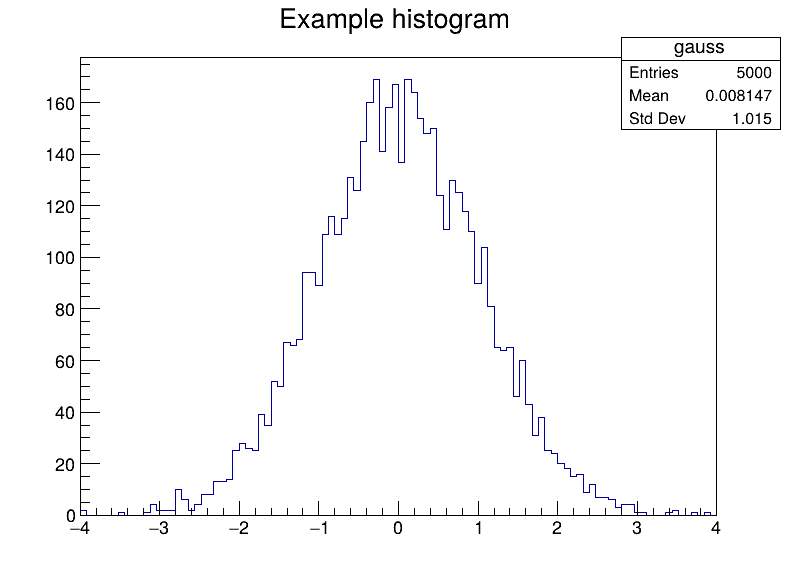

In [14]:
c = ROOT.TCanvas("myCanvasName","The Canvas Title",800,600)
h.Draw()
c.Draw()

It is not active by default yet, but Javascript visualisation can be activated for testing purposes. The plot below will be interactive: click on it and discover the [JSROOT](https://root.cern.ch/js/) capabilities!

In [15]:
%jsroot on
c.Draw()

In [16]:
c = ROOT.TCanvas("c")
h = ROOT.TH1F("h","ROOT Histogram;X;Y",64,-4,4)

Thanks to ROOT, it is possibile to write cells in C++ within a Python notebook. This can be done using the ``%%cpp`` magic. Magics are a feature of Jupyter notebooks and when importing the ROOT module, the ``%%cpp`` magic was registered.

In [17]:
%%cpp
cout << "This is a C++ cell" << endl;

This is a C++ cell


Another example to draw histogram with C++!

In [18]:
%%cpp
h->FillRandom("gaus");
h->Draw();
c->Draw();

###  ROOT as a function plotter

Using one of ROOT’s powerful classes, here TF1 will allow us to display a function of one variable, x. Try the following:

In [ ]:
c1 = ROOT.TCanvas("example","sin([1]*x)/x",800,600)
f1 = ROOT.TF1("f1","sin(x)/x",0.,10.)

``` f1 ``` is an instance of a ``` TF1 ``` class, the arguments are used in the constructor; the first one of type string is a name to be entered in the internal ROOT memory management system, the second string type parameter defines the function, here sin(x)/x, and the two parameters of type double define the range of the variable x.

In [ ]:
f1.Draw();
c1.Draw();

A slightly extended version of this example is the definition of a function with parameters, called [0], [1] and so on in the ROOT formula syntax. We now need a way to assign values to these parameters; this is achieved with the method [SetParameter](https://root.cern.ch/doc/master/classTF1.html#ade6e54171210c6b1b955c9f813040eb8)(``parameter_number``,``parameter_value``) of class TF1. Here is an example:

In [ ]:
f2 = ROOT.TF1("f2","[0]*sin([1]*x)/x",0.,10.)

You can try to change the parameters of the input below.

In [ ]:
f2.SetParameter(0,1)
f2.SetParameter(1,1)
f2.Draw()
c1.Draw()

### Use of Python Functions

It is possible to mix Python functions with ROOT and perform such operations as plotting and fitting of histograms with them. In all cases, the procedure consists of instantiating a ROOT ```TF1```, ```TF2```, or ```TF3``` with the Python function and working with that ROOT object. There are some memory issues, so it is for example not yet possible to delete a ```TF1``` instance and then create another one with the same name. In addition, the Python function, once used for instantiating the ```TF1```, is never deleted.

Instead of a Python function, you can also use callable instances (e.g., an instance of a class that has implemented the ```__call__``` member function). The signature of the Python callable should provide for one or two arrays. The first array, which must always be present, shall contain the ```x```, ```y```, ```z```, and t values for the call. The second array, which is optional and its size depends on the number given to the ```TF1``` constructor, contains the values that parameterize the function. For more details, see the ```TF1``` documentation and the examples below.

In [ ]:
from ROOT import TF1, TCanvas

#customized function
def identity( x, par): # python function gets two arguments : x, parameters
    return x[0]

# create an identity function
f = TF1('pyf1', identity, -1,1) #from -1 to 1
f.SetParameter(0,3)

# plot the function
c = TCanvas()
f.Draw()
c.Draw()

Because no number of parameters is given to the ```TF1``` constructor, ‘```0```’  (the default) is assumed. This way, the ‘```identity```’ function need not handle a second argument, which would normally be used to pass the function parameters. Note that the argument ‘```x```’ is an array of size 4. The following is an example of a parameterized Python callable instance that is plotted on a default canvas:

In [ ]:
from ROOT import TF1, TCanvas

class Linear:
    def __call__( self, x, par ):
        return par[0] + x[0]*par[1]

pyc = Linear()
# create a linear function with offset 5, and pitch 2
f = TF1('pyf2',pyc,-1.,1.,2)
# set parameters so that the function becomes y = 5+2x : ~two lines
# mini task
#f.SetParameter(0,5)
#f.SetParameter(1,2)

# plot the function
c = TCanvas()
f.Draw()
c.Draw()

Note that this time the constructor is told that there are two parameters, and note in particular how these parameters are set. It is, of course, also possible (and preferable if you only use the function for plotting) to keep the parameters as data members of the callable instance and use and set them directly from Python.

### Fitting Histograms

Fitting a histogram with a Python function is no more difficult than plotting: instantiate a ```TF1``` with the Python callable and supply that ```TF1``` as a parameter to the ```Fit()``` member function of the histogram. After the fit, you can retrieve the fit parameters from the ```TF1``` instance. For example:

In [ ]:
from ROOT import TF1, TH1F, TCanvas, TRandom3
# create and fill a histogram
h_data = TH1F('h_data','test',100,-1.,1.)
f2 = TF1('cf2','6.+x*4.5',-1.,1.)
h_data.FillRandom('cf2',10000)

# fit the histo with the python 'linear' function
h_data.Fit(f)

# print results
par = f.GetParameters()
print ('fit results: const =', par[0], ',pitch =', par[1])

##### answer:
```
fit results: const = 98.7442051575 ,pitch = 74.9120871231
```
Did you get the same answer? If not, why? Maybe it is because of random number generator?

### task

In [ ]:
# draw the histogram with the fit function: 3 lines


##### answer:
<img src="https://github.com/monttj/computational-physics/blob/2021/figs/c.png?raw=1" />

Did you get the same answer? If not, why?

### Working with trees

Next to making histograms, working with trees is probably the most common part of any analysis. The TTree implementation uses pointers and dedicated buffers to reduce the memory usage and to speed up access. Consequently, mapping TTree functionality to Python is not straightforward, and most of the following features are implemented in ROOT release 4.01/04 and later only, whereas you will need 5.02 if you require all of them.

#### Accessing an Existing Tree

Let us assume that you have a file containing TTrees, TChains, or TNtuples and want to read the contents for use in your analysis code. This is commonly the case when you work with the result of the reconstruction software of your experiment (e.g. the combined ntuple in ATLAS). The following example code outlines the main steps (you can run it on the result of the tree1.C macro):

In [ ]:
from ROOT import TChain, TFile

# open the file
chain = TChain("events");
chain.Add("files/data.root")

entries = chain.GetEntries()
print ("number of events = ", entries)

for i in range(entries):
    chain.GetEntry(i)
    print ("number of muons = ", chain.NMuon)
    if chain.NMuon > 0:
        print ("muon px = ", chain.Muon_Px[0], ", py = ", chain.Muon_Py[0], ", pz = ", chain.Muon_Pz[0])
        break

##### answer:
```
number of events =  469384
number of muons =  1
muon px =  4.85949611664 , py =  -30.2398738861 , pz =  137.776489258
```

We can print out only two decimal as we don't really need that much precision above.

In [ ]:
from ROOT import TChain, TFile

# open the file
chain = TChain("events");
chain.Add("files/data.root")

entries = chain.GetEntries()
print ("number of events = ", entries)

for i in range(entries):
    chain.GetEntry(i)
    print ("number of muons = ", chain.NMuon)
    if chain.NMuon > 0:
        # print out only two decimal : 3 lines
        px = "%.2f" % chain.Muon_Px[0]
        py = "%.2f" % chain.Muon_Py[0]
        pz = "%.2f" % chain.Muon_Pz[0]
        print ("muon px = ", px, ", py = ", py, ", pz = ", pz)
        break

##### answer:
```
number of events =  469384
number of muons =  1
muon px =  4.86 , py =  -30.24 , pz =  137.78
```

#### Writing a Tree

We will create a new variable of mass and save it into output file. The new variable is the mass which is defined as $M= \sqrt{ E^2 - P^2 }$

In [ ]:
from ROOT import TChain, TFile
import math

# open the file
chain = TChain("events");
chain.Add("files/data.root")

entries = chain.GetEntries()

for i in range(entries):
    chain.GetEntry(i)
    #we will calculate the mass using Einstein energy-momentum relation, E**2 = p**2 + m**2
    if chain.NMuon > 0:
        px = chain.Muon_Px[0]
        py = chain.Muon_Py[0]
        pz = chain.Muon_Pz[0]
        e = chain.Muon_E[0]
        mass = math.sqrt(e**2 - px**2 - py**2 - pz**2)
        print ("muon px = %.2f" % px, ", py = %.2f" % py, ", pz = %.2f" % pz, ", mass = %.2f" % mass)
        break

##### answer:
```
muon px = 4.86 , py = -30.24 , pz = 137.78 , mass = 0.12
```

The muon mass is 0.106 MeV. So it is not exactly the same but very similar. What would be the reason why it is not exactly the same?

In [ ]:
from ROOT import TChain, TFile
from ROOT import TTree
from array import array
import math

# open the file
chain = TChain("events");
chain.Add("files/data.root")

# create a new file that will contain the new variable, muon_mass
f = TFile('output.root', 'RECREATE')
t = TTree('tree', 'muon study')
muon_mass = array( 'd', [0] )
t.Branch('muon_mass', muon_mass, 'muon_mass/D')

entries = chain.GetEntries()

for i in range(entries):
    chain.GetEntry(i)
    #addtionally we will print out the process rate with following three lines
    #every 100000 events, we check how much it was processed
    process = float(i)/float(entries) * 100
    if i%100000 == 0:
        print ("processed = %.0f" % process,"%")
    #we will calculate the mass using Einstein energy-momentum relation, E**2 = p**2 + m**2
    if chain.NMuon > 0:
        px = chain.Muon_Px[0]
        py = chain.Muon_Py[0]
        pz = chain.Muon_Pz[0]
        e = chain.Muon_E[0]
        m2 = e**2 - px**2 - py**2 - pz**2
        # following lines are for saving new variable in new root file
        if m2 > 0:
            mass = math.sqrt(e**2 - px**2 - py**2 - pz**2)
            muon_mass[0] = mass
            t.Fill()
            continue
print ("done")
f.Write()
f.Close()

##### answer:
```
processed = 0 %
processed = 21 %
processed = 43 %
processed = 64 %
processed = 85 %
done
```

In [ ]:
!ls *.root

Can you open the newly created root file and access to the new variable, **muon_mass** and print out every 100000th events?

In [ ]:
from ROOT import TChain, TFile

# open the file
chain = TChain("tree");
chain.Add("output.root")

entries = chain.GetEntries()
print ("total number of events = ", entries)
for i in range(entries):
    # require one line to read event information, please see above if you are not sure
    if i%100000 == 0:
        #print out the new variable
        print ("muon mass = ")
print ("done")

##### answer

```
total number of events =  241918
muon mass =  0.116012407528
muon mass =  0.104943080381
muon mass =  0.105613876053
done
```

Now we will fill the histogram with this new variable

In [ ]:
from ROOT import TChain, TFile, TH1F, TCanvas

# open the file
chain = TChain("tree");
chain.Add("output.root")

#create histogram object in the range from 0 to 0.3 with 30 bins

entries = chain.GetEntries()
print ("total number of events = ", entries)
for i in range(entries):
    # need around 4 lines including the lines that are required in the previous example

print ("done")
c = TCanvas()
h_mass.Draw()
c.Draw()

##### answer

```
total number of events =  241918
muon mass =  0.116012407528
muon mass =  0.104943080381
muon mass =  0.105613876053
done
```

<img src="https://github.com/monttj/computational-physics/blob/2025/figs/muonmass.png?raw=1">

#### Dimuon mass

We will create a new variable for dimuon mass. We will do the vector sum of two muons.

For this, we need to make sure if there are at least two muons per event.
```python
    if chain.NMuon > 1:
```

In [ ]:
from ROOT import TChain, TFile
from ROOT import TTree
from array import array
import math

# open the file
chain = TChain("events");
chain.Add("files/data.root")

f = TFile( 'output2.root', 'RECREATE')
t = TTree( 'tree', 'muon study')
dimuon_mass = array( 'd', [0] )
t.Branch('dimuon_mass', dimuon_mass, 'dimuon_mass/D')

entries = chain.GetEntries()

for i in range(entries):
    chain.GetEntry(i)
    process = float(i)/float(entries) * 100
    if i%100000 == 0:
        print ("processed = %.0f" % process,"%")
    #we will calculate the mass using Einstein energy-momentum relation, E**2 = p**2 + m**2
    if chain.NMuon > 1:
        # print out only two decimal : 3 lines
        px1 = chain.Muon_Px[0]
        py1 = chain.Muon_Py[0]
        pz1 = chain.Muon_Pz[0]
        e1 = chain.Muon_E[0]
        px2 = chain.Muon_Px[1]
        py2 = chain.Muon_Py[1]
        pz2 = chain.Muon_Pz[1]
        e2 = chain.Muon_E[1]
        m2 = (e1+e2)**2 - (px1+px2)**2 - (py1+py2)**2 - (pz1+pz2)**2
        if m2 > 0:
            mass = math.sqrt(m2)
            dimuon_mass[0] = mass
            t.Fill()
            continue
print ("done")
f.Write()
f.Close()

Now we will repeat the same thing for the new variable, in this time, **dimuon_mass**. Can you write a code to read the dimuon_mass and print out the variable every 100000th events and fill the histogram with this variable and draw?

In [ ]:
from ROOT import TChain, TFile

# open the file
chain = TChain("tree");
chain.Add("output2.root")

#need one line to create histogram object

entries = chain.GetEntries()
print ("total number of events = ", entries)
for i in range(entries):
    #need one line to read event information
    #chain.GetEntry(i)
    #need around one line to fill the histogram
    #dimuon_mass=chain.dimuon_mass
    #h_dimass.Fill(dimuon_mass)
    if i%100000 == 0:
        #and print out
        print ("muon mass = ",dimuon_mass)
print ("done")
c = TCanvas()
h_dimass.Draw()
c.Draw()

##### answer:

```
total number of events =  18708
muon mass =  88.9468251097
done
```

<img src="https://github.com/monttj/computational-physics/blob/2025/figs/dimuonmass.png?raw=1">